<a href="https://colab.research.google.com/github/serghino/MGL869-01-2026-mining-challenge/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Étape 1: Installation des bibliothèques d'analyse de sentiment

In [1]:
# Installation des bibliothèques nécessaires
!pip install vaderSentiment textblob nltk pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.3 MB/s eta 0:00:00


## Étape 2: Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import nltk

# Télécharger les ressources NLTK nécessaires
nltk.download('punkt')
nltk.download('brown')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


## Étape 3: Chargement des données

In [3]:
# Chargement des datasets
pr_comments_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_comments.parquet")
pr_reviews_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_reviews.parquet")
pr_review_comments_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_review_comments_v2.parquet")

# Charger les PRs (pour identifier AI vs Human)
pull_request_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")

print(f"Nombre de commentaires PR: {len(pr_comments_df)}")
print(f"Nombre de reviews: {len(pr_reviews_df)}")
print(f"Nombre de commentaires de review: {len(pr_review_comments_df)}")
print(f"Nombre de PRs: {len(pull_request_df)}")

Nombre de commentaires PR: 39122
Nombre de reviews: 28875
Nombre de commentaires de review: 26868
Nombre de PRs: 33596


## Étape 4: Fonctions d'analyse de sentiment

Nous utilisons deux approches complémentaires:

### 1. VADER (Valence Aware Dictionary and sEntiment Reasoner)
- Optimisé pour les textes courts et informels (comme les commentaires GitHub)
- Retourne 4 scores: négatif, neutre, positif, et composé
- Le score composé varie de -1 (très négatif) à +1 (très positif)

### 2. TextBlob
- Retourne la polarité (-1 à +1) et la subjectivité (0 à 1)
- Utile pour comparer avec VADER

In [4]:
# Initialiser l'analyseur VADER
vader_analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment_vader(text):
    """
    Analyse le sentiment avec VADER.
    Retourne un dictionnaire avec les scores: neg, neu, pos, compound
    """
    if pd.isna(text) or text == "":
        return {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0}

    scores = vader_analyzer.polarity_scores(str(text))
    return scores

def analyze_sentiment_textblob(text):
    """
    Analyse le sentiment avec TextBlob.
    Retourne un dictionnaire avec polarity et subjectivity
    """
    if pd.isna(text) or text == "":
        return {'polarity': 0, 'subjectivity': 0}

    blob = TextBlob(str(text))
    return {
        'polarity': blob.sentiment.polarity,
        'subjectivity': blob.sentiment.subjectivity
    }

def categorize_sentiment(compound_score):
    """
    Catégorise le sentiment selon le score composé VADER:
    - Positif: >= 0.05
    - Neutre: entre -0.05 et 0.05
    - Négatif: <= -0.05
    """
    if compound_score >= 0.05:
        return 'positif'
    elif compound_score <= -0.05:
        return 'négatif'
    else:
        return 'neutre'

print("✓ Fonctions d'analyse de sentiment définies")

✓ Fonctions d'analyse de sentiment définies


## Étape 5: Test des fonctions avec des exemples

In [5]:
# Exemples de commentaires pour tester
test_comments = [
    "Great job! This code is excellent and well-documented.",
    "This is terrible code. Please fix it immediately.",
    "The implementation looks correct. Added some minor suggestions.",
    "LGTM! Thanks for the contribution 👍",
    "This breaks the entire application. Did you even test this?"
]

print("="*80)
print("TESTS D'ANALYSE DE SENTIMENT")
print("="*80)

for i, comment in enumerate(test_comments, 1):
    vader_scores = analyze_sentiment_vader(comment)
    textblob_scores = analyze_sentiment_textblob(comment)
    category = categorize_sentiment(vader_scores['compound'])

    print(f"\n{i}. Commentaire: \"{comment}\"")
    print(f"   VADER Compound: {vader_scores['compound']:.3f} (neg={vader_scores['neg']:.2f}, neu={vader_scores['neu']:.2f}, pos={vader_scores['pos']:.2f})")
    print(f"   TextBlob Polarity: {textblob_scores['polarity']:.3f}, Subjectivity: {textblob_scores['subjectivity']:.3f}")
    print(f"   → Catégorie: {category.upper()}")

TESTS D'ANALYSE DE SENTIMENT

1. Commentaire: "Great job! This code is excellent and well-documented."
   VADER Compound: 0.844 (neg=0.00, neu=0.43, pos=0.57)
   TextBlob Polarity: 1.000, Subjectivity: 0.875
   → Catégorie: POSITIF

2. Commentaire: "This is terrible code. Please fix it immediately."
   VADER Compound: -0.202 (neg=0.27, neu=0.53, pos=0.20)
   TextBlob Polarity: -1.000, Subjectivity: 1.000
   → Catégorie: NÉGATIF

3. Commentaire: "The implementation looks correct. Added some minor suggestions."
   VADER Compound: 0.000 (neg=0.00, neu=1.00, pos=0.00)
   TextBlob Polarity: -0.050, Subjectivity: 0.200
   → Catégorie: NEUTRE

4. Commentaire: "LGTM! Thanks for the contribution 👍"
   VADER Compound: 0.493 (neg=0.00, neu=0.65, pos=0.35)
   TextBlob Polarity: 0.200, Subjectivity: 0.200
   → Catégorie: POSITIF

5. Commentaire: "This breaks the entire application. Did you even test this?"
   VADER Compound: 0.000 (neg=0.00, neu=1.00, pos=0.00)
   TextBlob Polarity: 0.000, Subjecti

## Étape 7: Appliquer l'analyse de sentiment aux commentaires

Nous allons analyser tous les types de commentaires:
1. **pr_comments**: Commentaires généraux sur la PR
2. **pr_reviews**: Reviews complètes
3. **pr_review_comments**: Commentaires inline sur le code

In [ ]:
def add_sentiment_analysis(df, text_column='body'):
    """
    Ajoute les colonnes d'analyse de sentiment à un DataFrame.
    """
    print(f"Analyse de {len(df)} commentaires...")

    # Analyse VADER
    vader_results = df[text_column].apply(analyze_sentiment_vader)
    df['vader_neg'] = vader_results.apply(lambda x: x['neg'])
    df['vader_neu'] = vader_results.apply(lambda x: x['neu'])
    df['vader_pos'] = vader_results.apply(lambda x: x['pos'])
    df['vader_compound'] = vader_results.apply(lambda x: x['compound'])

    # Analyse TextBlob
    textblob_results = df[text_column].apply(analyze_sentiment_textblob)
    df['textblob_polarity'] = textblob_results.apply(lambda x: x['polarity'])
    df['textblob_subjectivity'] = textblob_results.apply(lambda x: x['subjectivity'])

    # Catégorisation
    df['sentiment_category'] = df['vader_compound'].apply(categorize_sentiment)

    print("✓ Analyse terminée")
    return df

# Note: L'exécution peut prendre quelques minutes selon la taille des datasets
print("Lancement de l'analyse des commentaires...")

# Analyse des commentaires de PR
print("\n1. Analyse des commentaires de PR (pr_comments)...")
pr_comments_with_sentiment = add_sentiment_analysis(pr_comments_df.copy())

# Analyse des reviews (si nécessaire, peut être long)
print("\n2. Analyse des reviews (pr_reviews)...")
pr_reviews_with_sentiment = add_sentiment_analysis(pr_reviews_df.copy())

# Analyse des commentaires de review (souvent le plus volumineux)
print("\n3. Analyse des commentaires de review (pr_review_comments)...")
pr_review_comments_with_sentiment = add_sentiment_analysis(pr_review_comments_df.copy())

print("\nAnalyse complète terminée !")

Prêt à analyser les commentaires!

Pour lancer l'analyse, décommentez et exécutez:
# pr_comments_with_sentiment = add_sentiment_analysis(pr_comments_df.copy())
# pr_reviews_with_sentiment = add_sentiment_analysis(pr_reviews_df.copy())
# pr_review_comments_with_sentiment = add_sentiment_analysis(pr_review_comments_df.copy())


## Étape 8: Analyse d'un échantillon (pour test rapide)

In [18]:
# Analyser un échantillon pour tester rapidement
sample_size = 1000

print(f"Analyse d'un échantillon de {sample_size} commentaires...\n")

# Échantillon de pr_comments
pr_comments_sample = pr_comments_df.sample(n=min(sample_size, len(pr_comments_df)), random_state=42).copy()
pr_comments_sample = add_sentiment_analysis(pr_comments_sample)

print("\n" + "="*80)
print("RÉSUMÉ DES SENTIMENTS (Échantillon)")
print("="*80)
print("\nDistribution des catégories de sentiment:")
print(pr_comments_sample['sentiment_category'].value_counts())
print(f"\nPourcentages:")
print(pr_comments_sample['sentiment_category'].value_counts(normalize=True) * 100)

print(f"\n\nStatistiques VADER Compound Score:")
print(pr_comments_sample['vader_compound'].describe())

print(f"\n\nStatistiques TextBlob Polarity:")
print(pr_comments_sample['textblob_polarity'].describe())

Analyse d'un échantillon de 1000 commentaires...

Analyse de 1000 commentaires...
✓ Analyse terminée

RÉSUMÉ DES SENTIMENTS (Échantillon)

Distribution des catégories de sentiment:
sentiment_category
positif    444
négatif    352
neutre     204
Name: count, dtype: int64

Pourcentages:
sentiment_category
positif    44.4
négatif    35.2
neutre     20.4
Name: proportion, dtype: float64


Statistiques VADER Compound Score:
count    1000.000000
mean        0.112932
std         0.535761
min        -0.997500
25%        -0.224400
50%         0.000000
75%         0.509300
max         0.999800
Name: vader_compound, dtype: float64


Statistiques TextBlob Polarity:
count    1000.000000
mean        0.044830
std         0.276801
min        -0.800000
25%        -0.008482
50%         0.035498
75%         0.193068
max         1.000000
Name: textblob_polarity, dtype: float64


## Étape 9: Visualisation des résultats

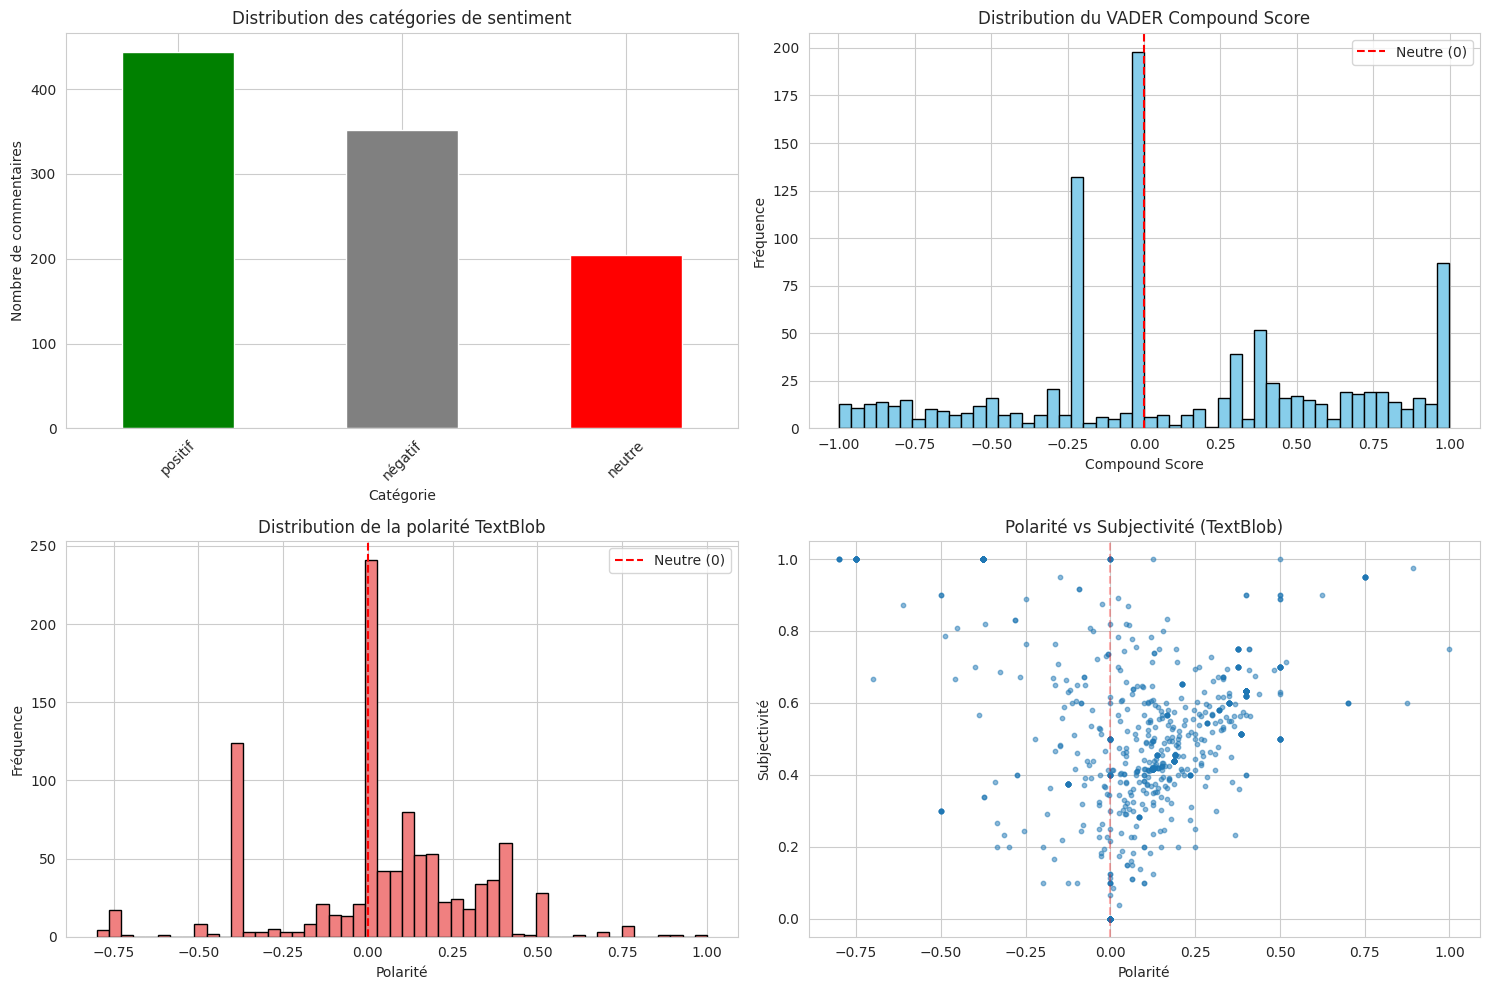


✓ Visualisations générées


In [9]:
# Créer des visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution des catégories de sentiment
pr_comments_sample['sentiment_category'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'gray', 'red'])
axes[0, 0].set_title('Distribution des catégories de sentiment')
axes[0, 0].set_xlabel('Catégorie')
axes[0, 0].set_ylabel('Nombre de commentaires')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Distribution du score VADER Compound
axes[0, 1].hist(pr_comments_sample['vader_compound'], bins=50, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Distribution du VADER Compound Score')
axes[0, 1].set_xlabel('Compound Score')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(x=0, color='red', linestyle='--', label='Neutre (0)')
axes[0, 1].legend()

# 3. Distribution de la polarité TextBlob
axes[1, 0].hist(pr_comments_sample['textblob_polarity'], bins=50, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Distribution de la polarité TextBlob')
axes[1, 0].set_xlabel('Polarité')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].axvline(x=0, color='red', linestyle='--', label='Neutre (0)')
axes[1, 0].legend()

# 4. Relation entre polarité et subjectivité
axes[1, 1].scatter(pr_comments_sample['textblob_polarity'],
                   pr_comments_sample['textblob_subjectivity'],
                   alpha=0.5, s=10)
axes[1, 1].set_title('Polarité vs Subjectivité (TextBlob)')
axes[1, 1].set_xlabel('Polarité')
axes[1, 1].set_ylabel('Subjectivité')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualisations générées")

## Étape 10: Exemples de commentaires par catégorie

In [10]:
def show_examples_by_sentiment(df, n=3):
    """
    Affiche des exemples de commentaires pour chaque catégorie de sentiment.
    """
    for category in ['positif', 'neutre', 'négatif']:
        print(f"\n{'='*80}")
        print(f"EXEMPLES DE COMMENTAIRES {category.upper()}S")
        print(f"{'='*80}\n")

        examples = df[df['sentiment_category'] == category].nlargest(n, 'vader_compound' if category == 'positif' else 'vader_neg')

        for idx, row in examples.iterrows():
            print(f"Commentaire: {row['body'][:200]}..." if len(str(row['body'])) > 200 else f"Commentaire: {row['body']}")
            print(f"VADER Compound: {row['vader_compound']:.3f}")
            print(f"TextBlob Polarity: {row['textblob_polarity']:.3f}")
            print("-" * 80)

show_examples_by_sentiment(pr_comments_sample, n=3)


EXEMPLES DE COMMENTAIRES POSITIFS

Commentaire: <details><summary>Builds ready [9ff0f88]</summary><ul><li>builds: <a href="https://diuv6g5fj9pvx.cloudfront.net/metamask-extension/16576310268/build-dist-browserify/builds/metamask-chrome-12.23.0.zip"...
VADER Compound: 1.000
TextBlob Polarity: 0.221
--------------------------------------------------------------------------------
Commentaire: ## PR Code Suggestions ✨

<!-- 2da08f2 -->

Explore these optional code suggestions:

<table><thead><tr><td><strong>Category</strong></td><td align=left><strong>Suggestion&nbsp; &nbsp; &nbsp; &nbsp; &...
VADER Compound: 1.000
TextBlob Polarity: 0.045
--------------------------------------------------------------------------------
Commentaire: <!-- This is an auto-generated comment: summarize by coderabbit.ai -->
<!-- walkthrough_start -->

## Walkthrough

The changes update type exports in two files: `TextContent` is now exported from the ...
VADER Compound: 0.999
TextBlob Polarity: 0.109
----------

## Étape 11: Identification des PRs (IA vs Humain) et Fusion des données

Pour répondre à l'hypothèse, nous devons distinguer les PRs créées par des agents IA de celles créées par des humains. Nous utiliserons la colonne `agent` du dataframe `pull_request_df`.

In [ ]:
# 1. Identifier les PRs IA vs Humaines
# Si 'agent' est rempli, c'est une IA. Sinon (None/NaN), c'est un humain.
pull_request_df['is_ai'] = pull_request_df['agent'].notna() & (pull_request_df['agent'] != '')

print("Distribution des PRs (IA vs Humain):")
print(pull_request_df['is_ai'].value_counts())
print("\nExemples d'agents détectés:")
print(pull_request_df[pull_request_df['is_ai']]['agent'].unique())

# 2. Fusionner les commentaires avec les informations de la PR
# Nous nous concentrons sur pr_comments_df pour cette analyse principale
merged_df = pr_comments_df.merge(
    pull_request_df[['id', 'is_ai', 'agent']], 
    left_on='pr_id', 
    right_on='id', 
    how='inner'
)

print(f"\nNombre total de commentaires après fusion: {len(merged_df)}")

## Étape 12: Analyse comparative du sentiment

Nous allons maintenant comparer les scores de sentiment entre les deux groupes.

In [ ]:
# Analyser un échantillon représentatif pour la comparaison statistique
# (Utiliser tout le dataset si possible, sinon un grand échantillon)
SAMPLE_SIZE = 5000

# Équilibrer l'échantillon si nécessaire ou prendre un échantillon aléatoire stratifié
# Ici, nous prenons un échantillon aléatoire simple du dataset fusionné
if len(merged_df) > SAMPLE_SIZE:
    analysis_df = merged_df.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    analysis_df = merged_df.copy()

# Appliquer l'analyse de sentiment (si ce n'est pas déjà fait sur ce dataframe)
analysis_df = add_sentiment_analysis(analysis_df)

# Séparer les groupes
ai_comments = analysis_df[analysis_df['is_ai'] == True]
human_comments = analysis_df[analysis_df['is_ai'] == False]

print(f"Taille de l'échantillon analysé: {len(analysis_df)}")
print(f"- Commentaires sur PRs IA: {len(ai_comments)}")
print(f"- Commentaires sur PRs Humaines: {len(human_comments)}")

## Étape 13: Test d'Hypothèse (H0 vs H1)

**H0**: Pas de différence significative de ton.
**H1**: Ton plus positif pour les IA.

Nous utiliserons le test de Mann-Whitney U car les scores de sentiment ne suivent généralement pas une distribution normale.

In [ ]:
from scipy import stats

# Calcul des moyennes
mean_ai = ai_comments['vader_compound'].mean()
mean_human = human_comments['vader_compound'].mean()

print(f"Score moyen VADER (Compound) - IA: {mean_ai:.4f}")
print(f"Score moyen VADER (Compound) - Humain: {mean_human:.4f}")

# Test statistique (Mann-Whitney U)
# alternative='greater' pour tester si IA > Humain (H1 directionnelle)
# ou 'two-sided' pour tester juste une différence. Commençons par two-sided.
stat, p_value = stats.mannwhitneyu(ai_comments['vader_compound'], human_comments['vader_compound'], alternative='two-sided')

print(f"\nRésultats du test Mann-Whitney U:")
print(f"Statistique U: {stat}")
print(f"P-value: {p_value}")

# Interprétation
alpha = 0.05
print("\n--- CONCLUSION ---")
if p_value < alpha:
    print("Rejet de l'hypothèse nulle (H0).")
    if mean_ai > mean_human:
        print("Résultat: Les commentaires sur les PRs IA sont significativement plus positifs.")
        print("Cela supporte l'hypothèse H1.")
    else:
        print("Résultat: Les commentaires sur les PRs Humaines sont significativement plus positifs.")
        print("Cela contredit H1.")
else:
    print("Échec du rejet de l'hypothèse nulle (H0).")
    print("Pas de différence significative détectée entre les deux groupes.")

# Visualisation
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_ai', y='vader_compound', data=analysis_df, palette=['lightblue', 'lightgreen'])
plt.title('Distribution du Sentiment (VADER) : Humain (False) vs IA (True)')
plt.xlabel('Est une PR IA ?')
plt.ylabel('Score Compound VADER')
plt.show()